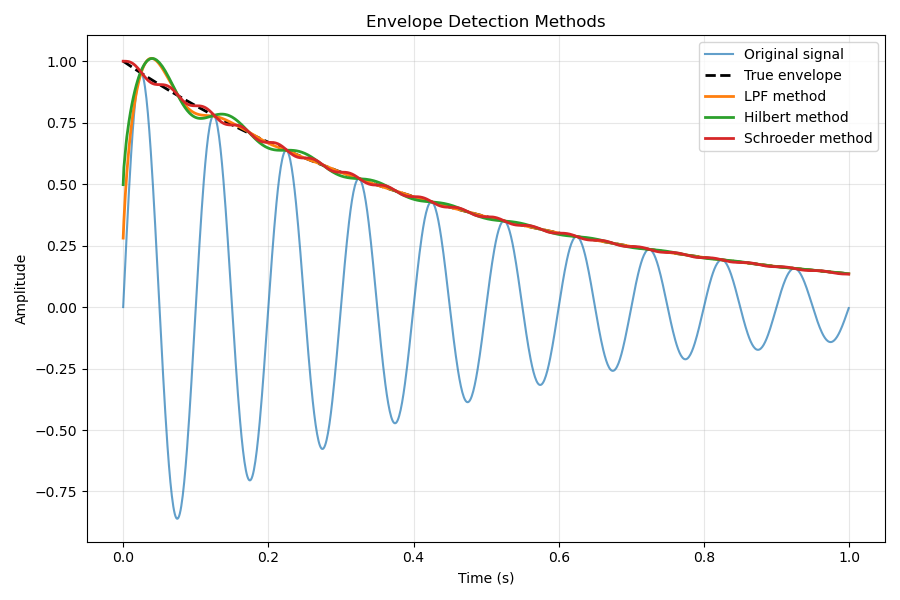

Mean Absolute Error - LPF method: 0.005697
Mean Absolute Error - Hilbert method: 0.014759
Mean Absolute Error - Schroeder method: 0.004498


In [11]:
import numpy as np
from scipy import signal
from scipy.signal import hilbert, butter, filtfilt

import matplotlib.pyplot as plt
%matplotlib widget

# Generate exponentially decaying sinusoid
fs = 1000  # Sampling frequency
t = np.linspace(0, 2, fs * 2)  # 2 seconds
f0 = 10  # Signal frequency
decay_rate = 2  # Decay constant

# Create exponentially decaying sinusoid
x = np.exp(-decay_rate * t) * np.sin(2 * np.pi * f0 * t)

# Method 1: Squared signal + Low-pass filter
x_squared = x**2
# Design low-pass filter
cutoff = 10  # Cutoff frequency
nyquist = fs / 2
normalized_cutoff = cutoff / nyquist
b, a = butter(4, normalized_cutoff, btype='low')
envelope_lpf = np.sqrt(2 * filtfilt(b, a, x_squared))

# Method 2: Hilbert transform
analytic_signal = hilbert(x)
envelope_hilbert = np.abs(analytic_signal)

# Method 3: Schroeder energy decay curve
x_squared_energy = x**2
# Reverse cumulative sum to get energy decay
energy_decay = np.cumsum(x_squared_energy[::-1])[::-1]
# Normalize and take square root to get envelope
envelope_schroeder = np.sqrt(energy_decay / energy_decay[0])

# True envelope for comparison
true_envelope = np.exp(-decay_rate * t)

# Plot results
plt.figure(figsize=(9, 6))

plt.subplot(1, 1, 1)
plt.plot(t[:1000], x[:1000], '-', label='Original signal', alpha=0.7)
plt.plot(t[:1000], true_envelope[:1000], 'k--', label='True envelope', linewidth=2)
plt.plot(t[:1000], envelope_lpf[:1000], '-', label='LPF method', linewidth=2)
plt.plot(t[:1000], envelope_hilbert[:1000], '-', label='Hilbert method', linewidth=2)
plt.plot(t[:1000], envelope_schroeder[:1000], '-', label='Schroeder method', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Envelope Detection Methods')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate and display errors
error_lpf = np.mean(np.abs(envelope_lpf - true_envelope))
error_hilbert = np.mean(np.abs(envelope_hilbert - true_envelope))
error_schroeder = np.mean(np.abs(envelope_schroeder - true_envelope))

print(f"Mean Absolute Error - LPF method: {error_lpf:.6f}")
print(f"Mean Absolute Error - Hilbert method: {error_hilbert:.6f}")
print(f"Mean Absolute Error - Schroeder method: {error_schroeder:.6f}")